### Install Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import xgboost as xgb
import sklearn
from sklearn.linear_model import LinearRegression

from scipy.stats import gaussian_kde
from scipy.interpolate import make_smoothing_spline

### Import Data

In [2]:
# Import data
data_train = pd.read_csv("../data/train.csv")
data_test = pd.read_csv("../data/test.csv")

### Descriptive Analysis

In [3]:
# General data descriptives
print(data_train.shape)
print(data_train.dtypes) 

(630000, 13)
id                    int64
age                   int64
gender                  str
course                  str
study_hours         float64
class_attendance    float64
internet_access         str
sleep_hours         float64
sleep_quality           str
study_method            str
facility_rating         str
exam_difficulty         str
exam_score          float64
dtype: object


In [4]:
# Export missing values for each column
missing = data_train.isnull().sum()
missing_pct = (missing / len(data_train) * 100).round(2)
print(pd.DataFrame({"missing": missing, "%": missing_pct}))

                  missing    %
id                      0  0.0
age                     0  0.0
gender                  0  0.0
course                  0  0.0
study_hours             0  0.0
class_attendance        0  0.0
internet_access         0  0.0
sleep_hours             0  0.0
sleep_quality           0  0.0
study_method            0  0.0
facility_rating         0  0.0
exam_difficulty         0  0.0
exam_score              0  0.0


In [5]:
# Column-level descriptives
data_train.describe()
data_train.describe(include="object")  

C:\Users\rfrost\AppData\Local\Temp\ipykernel_9924\3753852500.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data_train.describe(include="object")


,gender,course,internet_access,sleep_quality,study_method,facility_rating,exam_difficulty
count,630000,630000,630000,630000,630000,630000,630000
unique,3,7,2,3,5,3,3
top,other,b.tech,yes,poor,coaching,medium,moderate
freq,211097,131236,579423,213675,131697,214082,353982


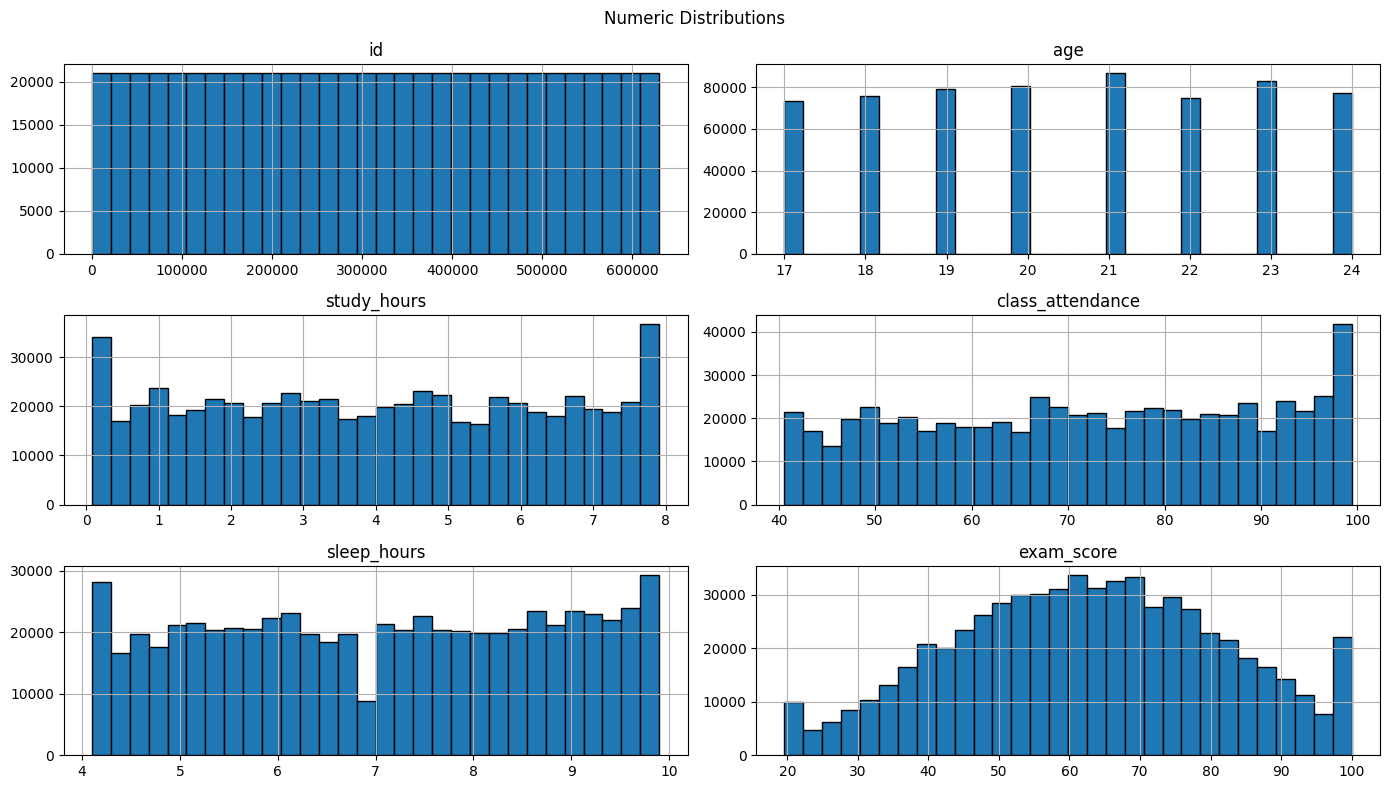

In [6]:
# Numeric descriptives
num_cols = data_train.select_dtypes(include=np.number).columns

data_train[num_cols].hist(figsize=(14, 8), bins=30, edgecolor="black")
plt.suptitle("Numeric Distributions")
plt.tight_layout()
plt.show()

In [7]:
# Categorical counts
cat_cols = data_train.select_dtypes(include="object").columns

for col in cat_cols:
    print(data_train[col].value_counts().head(10))
    print("\n")

C:\Users\rfrost\AppData\Local\Temp\ipykernel_9924\135827235.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = data_train.select_dtypes(include="object").columns


gender
other     211097
male      210593
female    208310
Name: count, dtype: int64


course
b.tech     131236
b.sc       111554
b.com      110932
bca         88721
bba         75644
ba          61989
diploma     49924
Name: count, dtype: int64


internet_access
yes    579423
no      50577
Name: count, dtype: int64


sleep_quality
poor       213675
good       213089
average    203236
Name: count, dtype: int64


study_method
coaching         131697
self-study       131131
mixed            123086
group study      123009
online videos    121077
Name: count, dtype: int64


facility_rating
medium    214082
low       212378
high      203540
Name: count, dtype: int64


exam_difficulty
moderate    353982
easy        176540
hard         99478
Name: count, dtype: int64




C:\Users\rfrost\AppData\Local\Temp\ipykernel_9924\1002782451.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = data_train.select_dtypes(include="object").columns


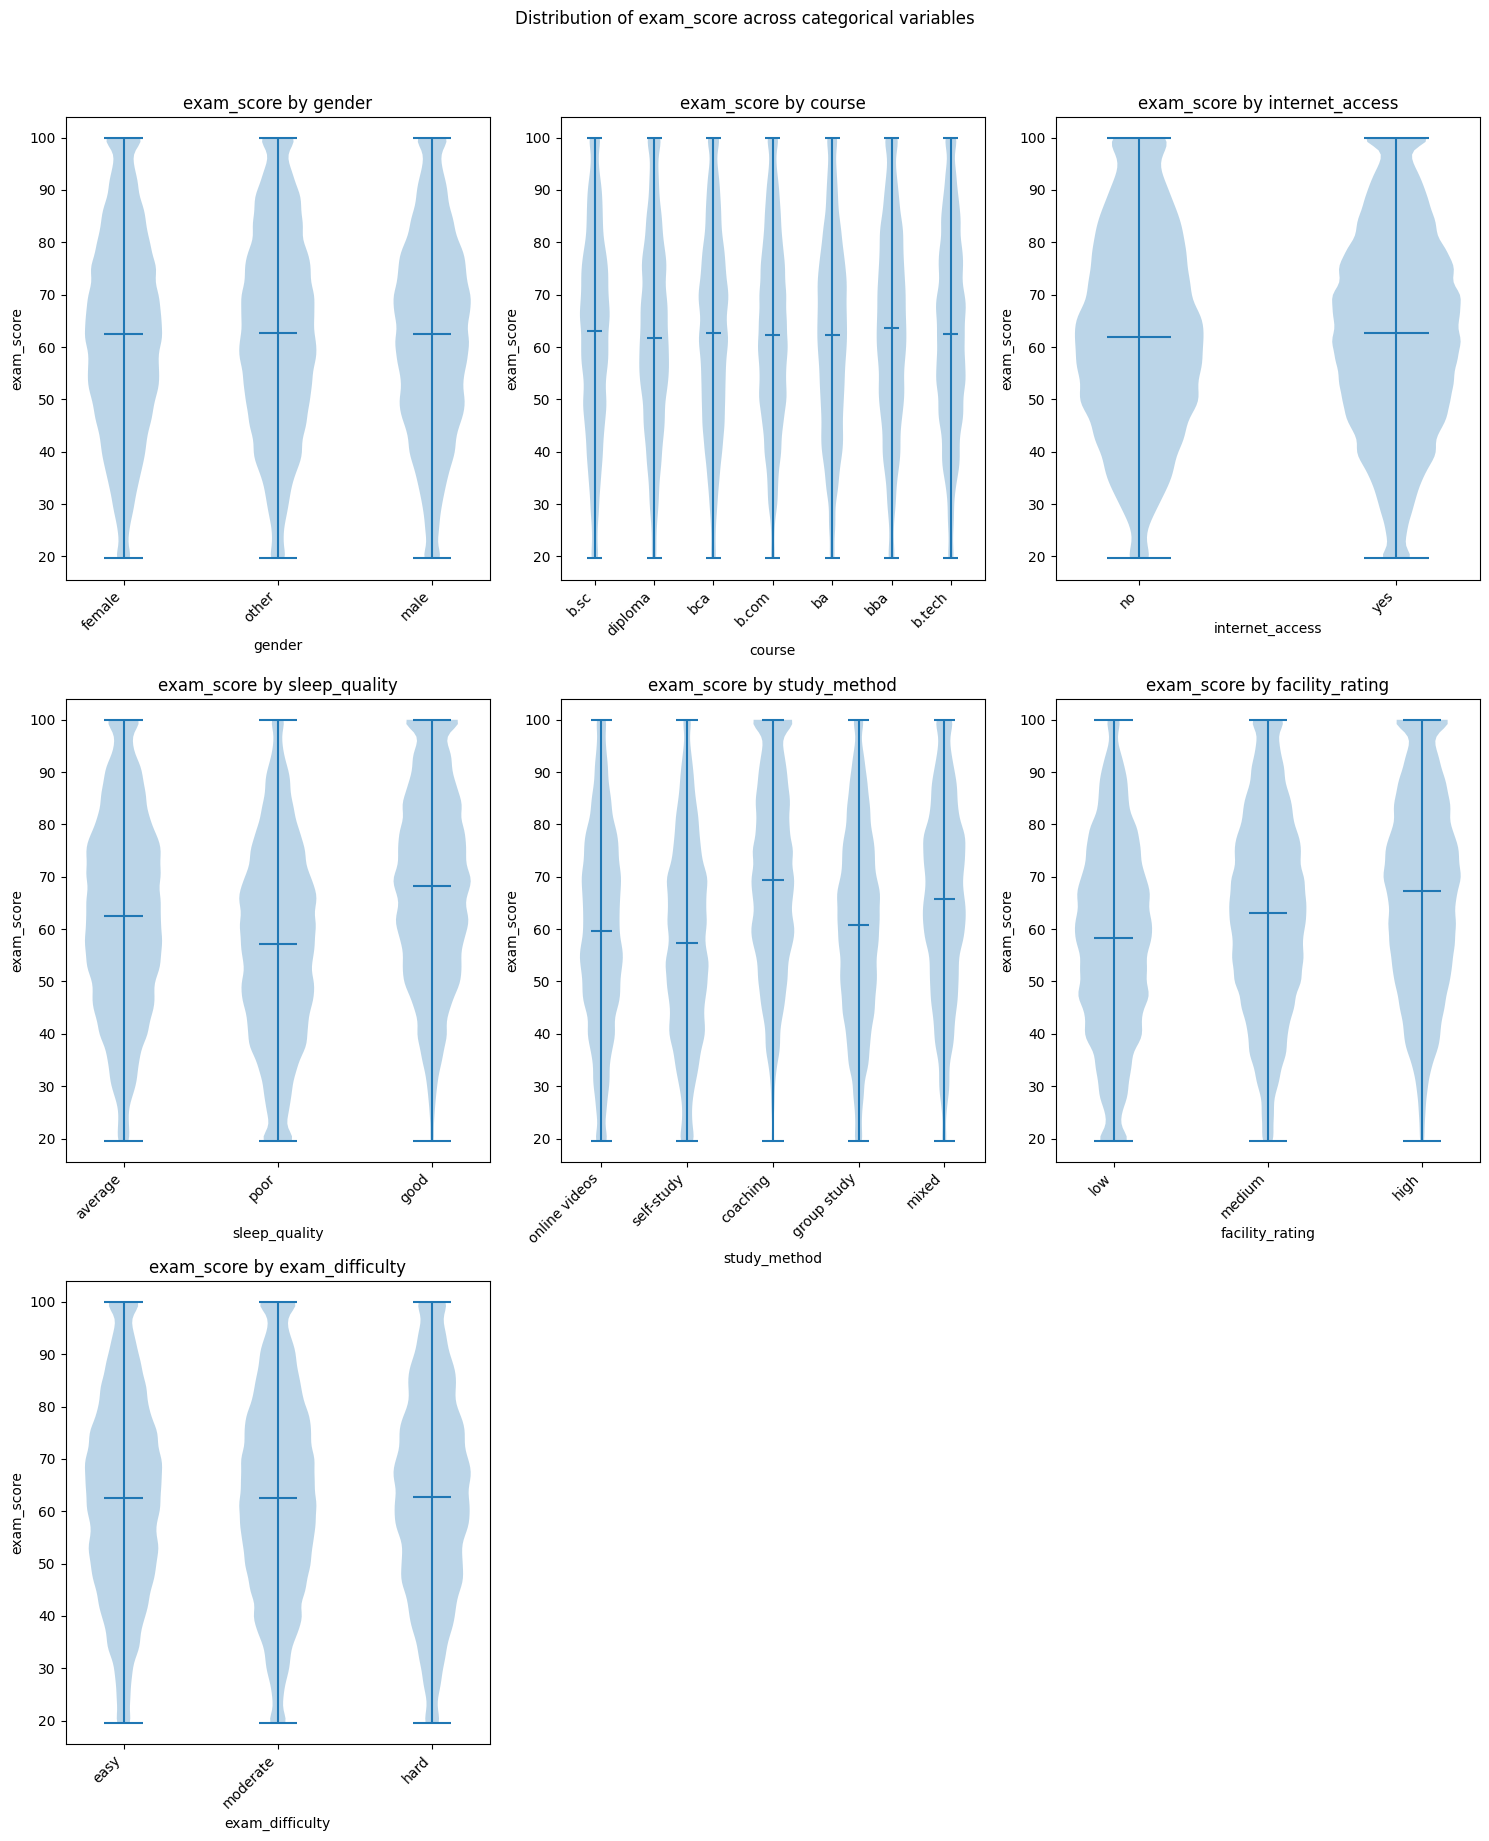

In [8]:
# Violin plots for the categorical variables against exam_score
cat_cols = data_train.select_dtypes(include="object").columns
target = "exam_score"

fig, axes = plt.subplots(3, math.ceil(len(cat_cols)/3), figsize=(5 * math.ceil(len(cat_cols)/3), 18))

axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    categories = data_train[col].dropna().unique()
    data = [data_train[data_train[col] == cat][target].dropna() for cat in categories]
    
    ax.violinplot(data, positions=range(len(categories)), showmedians=True)
    ax.set_xticks(range(len(categories)))
    ax.set_xticklabels(categories, rotation=45, ha="right")
    ax.set_title(f"{target} by {col}")
    ax.set_ylabel(target)
    ax.set_xlabel(col)

# Hide any unused subplots
for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f"Distribution of {target} across categorical variables", y=1.02)
plt.tight_layout()
plt.show()


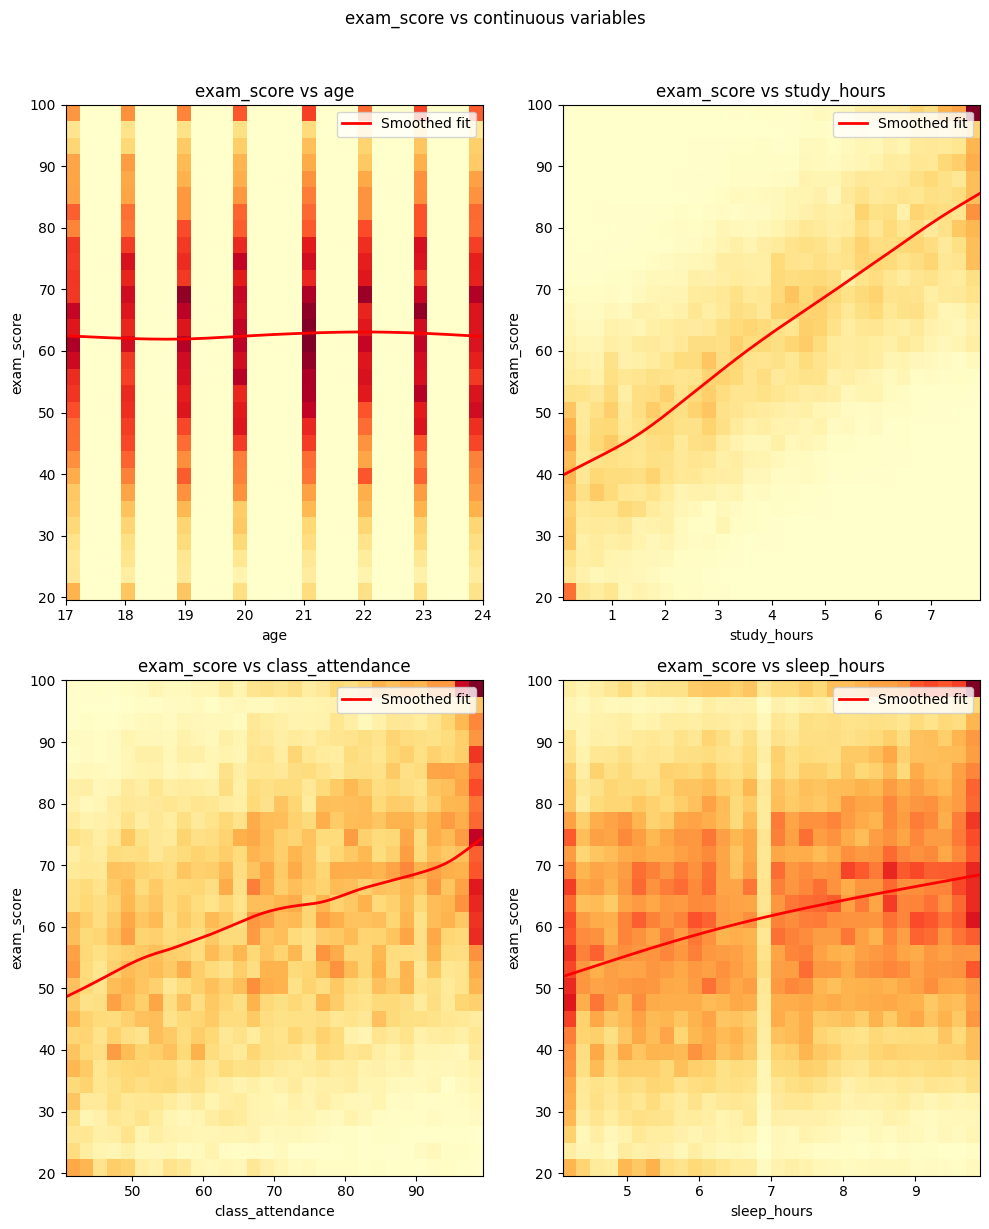

In [9]:
# Scatter plots by continuous variables
num_cols = [col for col in data_train.select_dtypes(include=np.number).columns if col not in [target, "id"]]
target = "exam_score"

n_cols = math.ceil(len(num_cols) / 2)
fig, axes = plt.subplots(2, n_cols, figsize=(5 * n_cols, 12))

axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    
    x = data_train[col].dropna().values
    y = data_train.loc[data_train[col].dropna().index, target].values

    # Sort by x
    sorted_idx = np.argsort(x)
    x_sorted = x[sorted_idx]
    y_sorted = y[sorted_idx]

    # Average y values for duplicate x values
    x_unique, inverse = np.unique(x_sorted, return_inverse=True)
    y_unique = np.array([y_sorted[inverse == i].mean() for i in range(len(x_unique))])

    ax.hist2d(x_sorted, y_sorted, bins=30, cmap="YlOrRd")

    spline = make_smoothing_spline(x_unique, y_unique)
    x_smooth = np.linspace(x_unique.min(), x_unique.max(), 300)
    ax.plot(x_smooth, spline(x_smooth), color="red", linewidth=2, label="Smoothed fit")
        
    ax.set_title(f"{target} vs {col}")
    ax.set_xlabel(col)
    ax.set_ylabel(target)
    ax.legend()

# Hide unused subplots
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f"{target} vs continuous variables", y=1.02)
plt.tight_layout()
plt.show()

### Model 1 - Linear Model

#### Model fitting

In [10]:

from sklearn.preprocessing import OneHotEncoder

# Define X and y
predictors_cnt = [col for col in data_train.select_dtypes(include=np.number).columns if col not in ["exam_score", "id"]]
predictors_cat = data_train.select_dtypes(include="object").columns.tolist()
predictand = "exam_score"

# Continuous features
X_cnt = data_train[predictors_cnt].values

# One-hot encode the categorical predictors
encoder_one_hot = OneHotEncoder(sparse_output=False)
X_cat = encoder_one_hot.fit_transform(data_train[predictors_cat])

# Combine
X = np.hstack([X_cnt, X_cat])
y = data_train[predictand].values

# Fit linear regression
reg = LinearRegression().fit(X, y)


C:\Users\rfrost\AppData\Local\Temp\ipykernel_9924\259733816.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  predictors_cat = data_train.select_dtypes(include="object").columns.tolist()


#### Residual analysis

In [ ]:
# Evaluate model residuals
residuals = y - reg.predict(X)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# 1. Residuals vs Fitted
axes[0].hexbin(reg.predict(X), residuals, gridsize=30, cmap="YlOrRd", mincnt=1)
axes[0].axhline(0, color="blue", linewidth=1.5, linestyle="--")
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")

# 2. Histogram of residuals
axes[1].hist(residuals, bins=40, edgecolor="black", color="steelblue")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution")

# 3. Q-Q plot (normality check)
from scipy.stats import probplot
probplot(residuals, plot=axes[2])
axes[2].set_title("Q-Q Plot")

# 4. Scale-location (homoscedasticity check)
axes[3].hexbin(reg.predict(X), np.sqrt(np.abs(residuals)), gridsize=30, cmap="YlOrRd", mincnt=1)
axes[3].axhline(np.sqrt(np.abs(residuals)).mean(), color="blue", linewidth=1.5, linestyle="--")
axes[3].set_xlabel("Fitted values")
axes[3].set_ylabel("√|Residuals|")
axes[3].set_title("Scale-Location")

plt.suptitle("Residual Analysis", y=1.02)
plt.tight_layout()
plt.show()

#### Fit onto testing data

In [12]:
# Now fit onto testing data

# Continuous features
X_cnt = data_test[predictors_cnt].values

# One-hot encode the categorical predictors
encoder_one_hot = OneHotEncoder(sparse_output=False)
X_cat = encoder_one_hot.fit_transform(data_test[predictors_cat])

# Combine
X = np.hstack([X_cnt, X_cat])

pred_y = reg.predict(X)

# Get results
results = pd.DataFrame({
    "id": data_test["id"].values,
    "exam_score": pred_y
})

# Write to .csv
results.to_csv("../output/1_linear_model.csv", index = False)

### Model 2 - Linear regression (logit transform)

#### Model fitting

In [14]:
from scipy.special import logit, expit

# Define X and y
predictors_cnt = [col for col in data_train.select_dtypes(include=np.number).columns if col not in ["exam_score", "id"]]
predictors_cat = data_train.select_dtypes(include="object").columns.tolist()
predictand = "exam_score"

# Continuous features
X_cnt = data_train[predictors_cnt].values

# One-hot encode the categorical predictors
encoder_one_hot = OneHotEncoder(sparse_output=False)
X_cat = encoder_one_hot.fit_transform(data_train[predictors_cat])

# Combine
X = np.hstack([X_cnt, X_cat])
y = data_train[predictand].values

# Instate model
dtrain_reg = xgb.DMatrix(X, y, enable_categorical=True)

# Define hyperparameters
params = {"objective": "reg:squarederror"}

n = 10
model = xgb.train(
   params=params,
   dtrain=dtrain_reg,
   num_boost_round=n,
)

C:\Users\rfrost\AppData\Local\Temp\ipykernel_9924\3724186454.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  predictors_cat = data_train.select_dtypes(include="object").columns.tolist()


#### Fit onto testing data

In [15]:
# Now fit onto testing data

# Continuous features
X_cnt = data_test[predictors_cnt].values

# One-hot encode the categorical predictors
encoder_one_hot = OneHotEncoder(sparse_output=False)
X_cat = encoder_one_hot.fit_transform(data_test[predictors_cat])

# Combine
X = np.hstack([X_cnt, X_cat])
dtrain_reg = xgb.DMatrix(X, enable_categorical=True)

pred_y = model.predict(dtrain_reg)

# Get results
results = pd.DataFrame({
    "id": data_test["id"].values,
    "exam_score": pred_y
})

# Write to .csv
results.to_csv("../output/2_xgboost.csv", index = False)